# __📊SQL WORK ENVIROMENT - HOSPITAL DATASET ANALYSIS 🏥__
---


## 🚨 <b>¿Cómo usar este archivo?</b> 🤷🏻‍♂️

<p align="justify">
El presente archivo se constituye como una herramienta generadora de ambiente para el desarrollo de código SQL en Google Colab. Sus objetivo son: </p>

* <p align="justify"> Permitir al estudiante acceder a una base de datos que cuenta con más de 800,000 registros asociados a distintas variables relativas al rubro de prestación de servicios de salud (rubro hospitalario) :. </p>

* <p align="justify"> Generar un ambiente del trabajo donde los estudiantes puedan escribir, depurar y generar código SQL para realizar cosultas sobre la base de datos generada. </p>

* <p align="justify"> Aprender a usar SQL como herramienta de comunicación de insights y como pueden utilizarse para responder la pregunta de negocio o hipótesis que sea de interés para los stakeholders.
</p>

* <p align="justify">  Generar instancias que impliquen el manejo simultaneo de múltiples tablas en una base de datos.
</p>

<p align="justify">
El contexto viene dado por una 👉 <b><a href="https://github.com/hectorhormazabal-tt/TT-SQL-DA-95/blob/master/Data_set_hospital_generator.ipynb"> generación de data del rubro hospitalario/servicio de salud</a></b> 👈, que tiene por finalidad generar una instancia que permite al estudiante comprender la relación entre tablas, generación de consultas SQL de distinta complejidad, uso de CTE, filtros y sumarios.
</p>

---

## 🖊️📖✏️📚 __INSTRUCCIONES DE USO__ 📋

 <p align="justify">

* __STEP 1️⃣:__ <p align="justify">  El chunk de código que viene a continuación tiene <b>dos funciones principales:</b>
</p>

<p align="justify">

**(1) Conectar** nuestro entorno con las bases de datos generadas para nuestro propósito de aprendizaje.
</p>

<p align="justify">

**(2) Generar un entorno de programación en SQL** idéntico a los motores frecuentemente usados en la industrial.
</p>

<p align="justify">
<b>Si es de su interés</b>, puedes hacer click en el botón ✨<b><font color="7bf1a8">Mostrar código</font></b>✨, para poder ver con todo detalle el proceso mencionado en (1) y (2). Si no es así, simplemente omita esta opción. Sea cual sea el caso, <b><font color="ff6392">debe dar click en el botón de run</font> </b> para poder generar la base de datos y activar el ambiente.
</p>

<p align = "justify">
Listo! La base de datos ha sido generada y ya podemos ver las tablas disponibles (rutas). También el ambiente para poder generar SQL-queries ha sido activado.
</p>

* __STEP 2️⃣:__ <p align="justify">

 Listo! Luego del paso anterior, ya puedes comenzar a generar consultas en este Google Colab y consultar la base de datos que ha sido generada (usando sus rutas). Para eso, simplemente debemos crear un nuevo chunck de código y escribir al incio de este, la <b><font color="ffe45e">palabra mágica:🌠🌟</font></b> <b><font color="5aa9e6">%%sql</font></b>✨🔮 en nuestro chunck de código y listo ✅, en ese chunck puedes ejecutar código SQL como lo harías en cualquier plataforma 🛢️.
</p>


In [3]:
#@title 🛢️📊 __STEP 1:__ Conectémonos a nuestra base de datos y activemos nuestro ambiente 🚀 { display-mode: "form" }
import pandas as pd
import sqlite3
import time
from IPython.core.magic import register_cell_magic
from IPython.display import display, HTML, clear_output
from tqdm.notebook import tqdm

# 1. Configuración de enlaces
datasets = {
    'tt_da_95_data_hospital_diagnoses': "https://raw.githubusercontent.com/hectorhormazabal-tt/TT-SQL-DA-95/refs/heads/master/diagnoses_dim.csv",
    'tt_da_95_data_hospital_appointments': "https://raw.githubusercontent.com/hectorhormazabal-tt/TT-SQL-DA-95/refs/heads/master/emergency_appointments.csv",
    'tt_da_95_data_hospital_patients': "https://raw.githubusercontent.com/hectorhormazabal-tt/TT-SQL-DA-95/refs/heads/master/patients_dim.csv"
}

# 2. Conexión a la base de datos en memoria
connector = sqlite3.connect(':memory:')

# 3. Proceso de carga con Barra de Progreso Verde
print("⬇️🗂️ Initiating data download and synchronization.....🔄⚙️")
summary_data = []

# Usamos tqdm para la barra visual
for name, url in tqdm(datasets.items(), desc="Cargando Tablas", bar_format='{l_bar}{bar:20}| {n_fmt}/{total_fmt}'):
    # Descarga
    df = pd.read_csv(url)

    # Conversión a SQL
    df.to_sql(name, connector, index=False, if_exists='replace')

    # Guardar info para el resumen
    summary_data.append({
        "Table route": f"{name}",
        "Row": f"{len(df):,}",
        "Columns": len(df.columns)
    })
    time.sleep(0.5) # Breve delay para que la barra sea visible

# 4. Palabra mágica %%sql
@register_cell_magic
def sql(line, cell):
    try:
        resultado = pd.read_sql(cell, connector)
        clear_output(wait=True)
        display(HTML("<b style='color: #4CAF50;'>✅ Query completed successfully:</b>"))
        return display(resultado)
    except Exception as e:
        clear_output(wait=True)
        display(HTML(f"<b style='color: #F44336;'>❌ Query execution failed:</b><br><code style='color: grey;'>{str(e)}</code>"))

# 5. Interfaz final para el alumno
clear_output()
display(HTML("<h2 style='color: #8e62f3'>✨ Database initialized - Hospital data ✨</h2>"))
display(HTML("<p>Data has been successfully loaded. Please use these names for your queries:</p>"))

# Mostramos el resumen en una tabla estética
display(pd.DataFrame(summary_data))

print("\n ✨🏥 ALL DONE! YOU ARE READY TO PRACTICE YOUR QUERY SKILLS! 💊🌡️🩹💉🩺✨")

,Table route,Row,Columns
0,tt_da_95_data_hospital_diagnoses,15,6
1,tt_da_95_data_hospital_appointments,"800,000",11
2,tt_da_95_data_hospital_patients,"25,000",10



 ✨🏥 ALL DONE! YOU ARE READY TO PRACTICE YOUR QUERY SKILLS! 💊🌡️🩹💉🩺✨


### 📌__Sumario de las tablas__📋


<p align="justify">

<p align="justify"> <b>Table name:</b> <code style="color: #ffffff; background-color: #F0E325; padding: 2px 6px; border-radius: 4px;">tt_da_95_data_hospital_appointments</code> </p>

| Column name | Data type | Example | Description|
| :--- | :--- | :--- | :--- |
|**appointment_id**</font> | `INT` | `10` | Identificador único de la atención en urgencias. |
| **patient_id** | `TEXT` | `PAT-25-12835` | ID único del paciente (usar para `JOIN` con tabla de pacientes). |
| **icd10_id** | `TEXT` | `ICD-110` | Código internacional de enfermedad (usar para `JOIN` con diagnósticos). |
| **admission_date** | `TEXT` | `2025-07-21 23:54` | Fecha y hora exacta del ingreso del paciente. |
| **triage_level** | `TEXT` | `Red` | Gravedad del paciente: Rojo (Crítico), Amarillo (Urgente), Azul (No urgente). |
| **systolic_bp** | `INT` | `134` | Presión arterial sistólica (valor máximo). |
| **diastolic_bp** | `INT` | `104` | Presión arterial diastólica (valor mínimo). |
| **heart_rate** | `INT` | `82` | Frecuencia cardíaca medida en latidos por minuto (BPM). |
| **temp_celsius** | `FLOAT` | `36.9` | Temperatura corporal del paciente al ingresar. |
| **total_cost** | `FLOAT` | `3604.36` | Costo monetario total de la atención recibida. |
| **hospital_branch** | `TEXT` | `Polanco` | Nombre de la sucursal u hospital donde se realizó la atención. |

<br>
<p align="justify"> <b>Table name:</b> <code style="color: #ffffff; background-color: #F0E325; padding: 2px 6px; border-radius: 4px;">tt_da_95_data_hospital_diagnoses</code> </p>

| Column name | Data type | Example | Description|
| :--- | :--- | :--- | :--- |
| **icd10_id** | `TEXT` | `ICD-101` | Código identificador de la enfermedad (usar para `JOIN`). |
| **diagnosis_name** | `TEXT` | `Acute Myocardial Infarction` | Nombre clínico de la patología. |
| **medical_specialty** | `TEXT` | `Cardiology` | Especialidad médica encargada del caso. |
| **risk_score** | `INT` | `9` | Escala de riesgo (1-10) del diagnóstico. |
| **is_contagious** | `BOOLEAN` | `0` | Indica si es contagioso (1 = Sí, 0 = No). |
| **avg_recovery_weeks**| `INT` | `12` | Tiempo promedio estimado de recuperación en semanas. |

<br>
<p align="justify"> <b>Table name:</b> <code style="color: #ffffff; background-color: #F0E325; padding: 2px 6px; border-radius: 4px;">tt_da_95_data_hospital_patients 	</code> </p>

| Column name | Data type | Example | Description |
| :--- | :--- | :--- | :--- |
| **patient_id** | `TEXT` | `PAT-25-00001` | Identificador único del paciente (usar para `JOIN`). |
| **full_name** | `TEXT` | `Patient_1` | Nombre completo del paciente. |
| **gender** | `TEXT` | `F` | Género: F (Femenino), M (Masculino), NB (No binario). |
| **birth_date** | `TEXT` | `2009-10-06` | Fecha de nacimiento (útil para calcular la edad). |
| **occupation** | `TEXT` | `Student` | Ocupación o situación laboral actual. |
| **state_mx** | `TEXT` | `CDMX` | Estado de la República Mexicana donde reside. |
| **blood_type** | `TEXT` | `B+` | Grupo sanguíneo y factor Rh. |
| **height_m** | `FLOAT` | `1.63` | Altura del paciente medida en metros. |
| **weight_kg** | `FLOAT` | `91.7` | Peso del paciente medido en kilogramos. |
| **insurance_provider**| `TEXT` | `ISSSTE` | Institución o aseguradora del paciente (IMSS, GNP, etc.). |

###  👩🏻‍💻🕵🏻‍♂️ __STEP 2: Comencemos a hacer consultas!__ 🗂️📡👩🏻‍💻

## 📢<b> Ambiente de práctica </b> 💪🏼

<p align = "justify">
A continuación, nos pondremos en los zapatos de nuestros stakeholders y nos haremos preguntas que podrían llegar a ser de su interés, con el objetivo de orientar su proceso de toma de decisiones mediante el uso de SQL como herramienta dentro de nuestro arsenal como analistas de datos. </p>


#### 📑 <b> Antes de comenzar❗ Basic SQL sentences </b> 🔍
#### 🛠️ Diccionario Maestro de Sentencias SQL

| SQL Statement | Description | Classification |
| :--- | :--- | :--- |
| <font color="#7abaff">`SELECT`</font> | Selecciona columnas específicas para extraer datos de una tabla. | <font color="#7abaff">Selección</font> |
| <font color="#7abaff">`SELECT *`</font> | Selecciona todos los campos disponibles en una tabla. | <font color="#7abaff">Selección</font> |
| <font color="#7abaff">`DISTINCT`</font> | Extrae valores únicos, eliminando los duplicados de una columna. | <font color="#7abaff">Selección</font> |
| <font color="#ff6b6b">`WHERE`</font> | Filtra las filas que cumplen con una condición determinada. | <font color="#ff6b6b">Filtrado</font> |
| <font color="#ff6b6b">`AND` / `OR`</font> | Combina múltiples criterios de búsqueda en una misma consulta. | <font color="#ff6b6b">Filtrado</font> |
| <font color="#ff6b6b">`IN`</font> | Comprueba si un valor coincide con cualquier elemento de una lista. | <font color="#ff6b6b">Filtrado</font> |
| <font color="#ff6b6b">`LIKE`</font> | Busca un patrón específico dentro de una cadena de texto (comodín `%`). | <font color="#ff6b6b">Filtrado</font> |
| <font color="#ff6b6b">`BETWEEN`</font> | Filtra valores dentro de un rango numérico o de fechas definido. | <font color="#ff6b6b">Filtrado</font> |
| <font color="#ffd43b">`ORDER BY`</font> | Clasifica los resultados de forma ascendente (`ASC`) o descendente (`DESC`). | <font color="#ffd43b">Ordenamiento</font> |
| <font color="#8ce99a">`GROUP BY`</font> | Agrupa registros que tienen valores idénticos para realizar cálculos. | <font color="#8ce99a">Agregación</font> |
| <font color="#8ce99a">`COUNT()`</font> | Cuenta el número total de filas o registros en un grupo. | <font color="#8ce99a">Agregación</font> |
| <font color="#8ce99a">`SUM()`</font> | Suma todos los valores de una columna numérica. | <font color="#8ce99a">Agregación</font> |
| <font color="#8ce99a">`AVG()`</font> | Calcula el valor promedio de una columna numérica. | <font color="#8ce99a">Agregación</font> |
| <font color="#8ce99a">`MIN()` / `MAX()`</font> | Devuelve el valor mínimo o máximo de una columna respectivamente. | <font color="#8ce99a">Agregación</font> |
| <font color="#ff6b6b">`HAVING`</font> | Aplica condiciones de filtrado a los resultados de una agregación. | <font color="#ff6b6b">Filtrado de Agregados</font> |
| <font color="#cdb4db">**`TRIM()`**</font> | Elimina espacios en blanco innecesarios al inicio y al final de un texto. | <font color="#cdb4db">Limpieza</font> |
| <font color="#cdb4db">**`LENGTH()`**</font> | Devuelve la longitud de una cadena de texto. | <font color="#cdb4db">Limpieza / Análisis</font> |
| <font color="#cdb4db">**`CAST()`**</font> | Convierte una expresión de un tipo de dato a otro (ej. texto a número). | <font color="#cdb4db">Conversión / Limpieza</font> |
| <font color="#cdb4db">**`NULLIF()`**</font> | Retorna NULL si dos expresiones son iguales, evitando errores. | <font color="#cdb4db">Limpieza / Lógica</font> |
| <font color="#cdb4db">**`COALESCE()`**</font> | Devuelve el primer valor no nulo en una lista de argumentos. | <font color="#cdb4db">Lógica / Limpieza</font> |
| <font color="#8ce99a">**`ROUND()`**</font> | Redondea un valor numérico al número de decimales especificado. | <font color="#8ce99a">Transformación</font> |
| <font color="#cdb4db">**`CASE WHEN`**</font> | Permite ejecutar lógica condicional (Si... Entonces...) en la consulta. | <font color="#cdb4db">Lógica</font> |
| <font color="#ffd43b">**`INNER JOIN`**</font> | Combina filas de tablas cuando hay una coincidencia exacta. | <font color="#ffd43b">Relación</font> |
| <font color="#ffd43b">**`LEFT JOIN`**</font> | Mantiene las filas de la tabla izquierda y las coincidencias de la derecha. | <font color="#ffd43b">Relación</font> |
| <font color="#ffd43b">`JOIN`</font> | Alias común para `INNER JOIN` que combina tablas por columna común. | <font color="#ffd43b">Relación</font> |
| <font color="#ff6b6b">`LIMIT`</font> | Restringe la cantidad total de filas que devuelve la consulta. | <font color="#ff6b6b">Restricción</font> |

#### 📝 <b> SQL Query Template & Logic </b>

| Clause | Technical Syntax |
| :--- | :--- |
| **SELECT** | `SELECT col_1, SUM(col_2) AS alias` |
| **FROM** | `FROM table_name` |
| **WHERE** | `WHERE col_1 > value` |
| **GROUP BY** | `GROUP BY col_1` |
| **HAVING** | `HAVING SUM(col_2) > value` |
| **ORDER BY** | `ORDER BY alias DESC` |
| **LIMIT** | `LIMIT 10` |

#### 🗺️ __Mapa de Relaciones (Estructura de la DB)__ 🗺️

| <font color="#7abaff">TABLA PACIENTES</font> | ↔ | <font color="#8ce99a">TABLA CITAS (Eje Central)</font> | ↔ | <font color="#cdb4db">TABLA DIAGNÓSTICOS</font> |
| :--- | :---: | :--- | :---: | :--- |
| <font color="#7abaff">`patient_id`</font> **<font color="#ffd43b">(PK)</font>** | → | <font color="#8ce99a">`patient_id`</font> **<font color="#ffd43b">(FK)</font>** | | |
| | | <font color="#8ce99a">`icd10_id`</font> **<font color="#ffd43b">(FK)</font>** | ← | <font color="#cdb4db">`icd10_id`</font> **<font color="#ffd43b">(PK)</font>** |


#### 📝<b> Modelo Entidad-Relación (MER) </b> 📒 🔗‍️ 📘 🔗‍️ 📕
---
<pre style="background-color: #1e1e1e; color: #d4d4d4; padding: 25px; border-radius: 12px; line-height: 1.2; font-family: monospace; border: 1px solid #333; font-size: 14px; white-space: pre;">
<b style="color: #7abaff;">TABLA: tt_da_95_data_hospital_patients</b> (Catálogo de Personas)
<b style="color: #7abaff;">└──</b> <b style="color: #7abaff;">patient_id</b> <b style="color: #ffd43b;">[PK]</b> <b style="color: #ffd43b;">───────────┐</b>
    ├── full_name             <b style="color: #ffd43b;">│</b>
    ├── gender                <b style="color: #ffd43b;">│</b>
    └── state_mx              <b style="color: #ffd43b;">│</b>
                              <b style="color: #ffd43b;">│ (1:N)</b>
                              <b style="color: #ffd43b;">▼</b>
<b style="color: #8ce99a;">TABLA: tt_da_95_data_hospital_appointments</b> (Eje Central)
├── <b style="color: #8ce99a;">appointment_id</b> <b style="color: #ffd43b;">[PK]</b>
├── <b style="color: #ff6b6b;">patient_id</b>     <b style="color: #8ce99a;">[FK]</b> <span style="color: #666;">(Hacia Patients)</span>
├── <b style="color: #ff6b6b;">icd10_id</b>       <b style="color: #8ce99a;">[FK]</b> <span style="color: #666;">(Hacia Diagnoses)</span> <b style="color: #cdb4db;">──┐</b>
├── admission_date                        <b style="color: #cdb4db;">│</b>
└── total_cost                            <b style="color: #cdb4db;">│</b>
                                          <b style="color: #cdb4db;">│</b>
            <b style="color: #cdb4db;">┌─────────────────────────────┘</b>
            <b style="color: #cdb4db;">│ (1:N)</b>
            <b style="color: #cdb4db;">▼</b>
<b style="color: #cdb4db;">TABLA: tt_da_95_data_hospital_diagnoses</b> (Catálogo de Enfermedades)
<b style="color: #cdb4db;">└──</b> <b style="color: #cdb4db;">icd10_id</b>   <b style="color: #ffd43b;">[PK]</b>
    ├── diagnosis_name
    └── medical_specialty
</pre>

#### 🤝 <b> Jerarquía de Conexión: </b>🔗
<p align = "justify"

<b>1. Pacientes a Citas:</b> Relación (1:N). Un paciente puede tener muchas citas. Se conectan por `patient_id`. </p>

<p align = "justify"

<b>2. **Diagnósticos a Citas:**</b> Relación (1:N). Un diagnóstico puede estar en muchas citas. Se conectan por `icd10_id`. </p>

#### 🤝**SQL JOINS**🔗

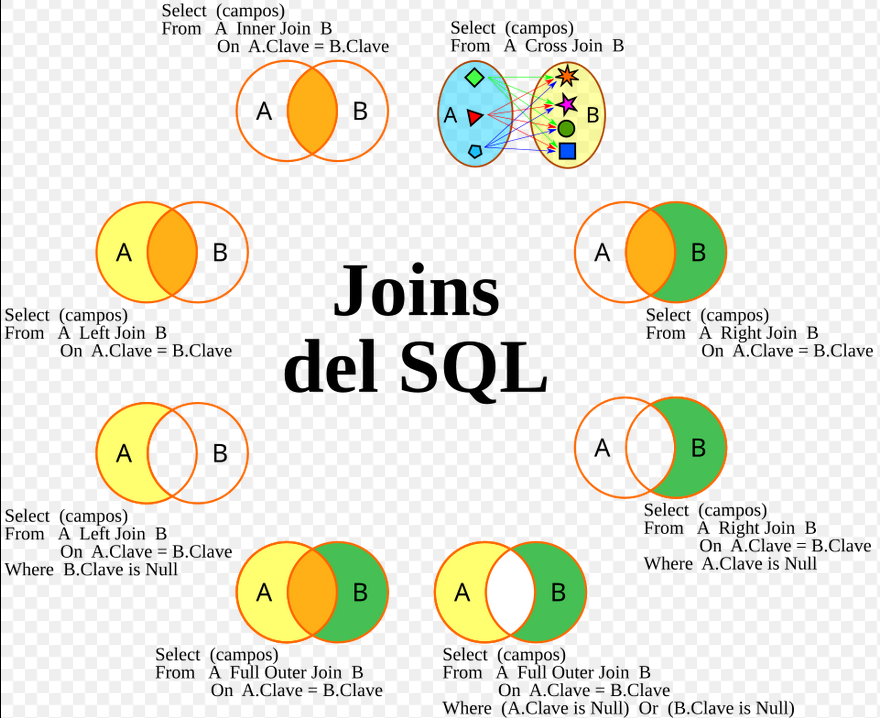

---

#### <b>🧩Basic query examples </b>💡

In [4]:
%%sql
-- Retornar los primeros 10 registros de la tabla:tt_da_95_data_hospital_appointments
SELECT
admission_date, patient_id, triage_level, heart_rate, temp_celsius
FROM tt_da_95_data_hospital_appointments LIMIT 5

,admission_date,patient_id,triage_level,heart_rate,temp_celsius
0,2025-07-21 23:54:00,PAT-25-12835,Yellow,82,36.9
1,2025-09-24 09:19:00,PAT-25-23799,Blue,53,37.8
2,2025-03-25 12:15:00,PAT-25-17072,Red,102,36.6
3,2025-08-21 21:54:00,PAT-25-02907,Red,59,37.6
4,2025-12-29 13:26:00,PAT-25-22416,Yellow,110,37.2


In [3]:
%%sql
-- Encontrar registros en la tabla tt_da_95_data_hospital_patients donde el capo gender es vacio/empty?
SELECT *
FROM tt_da_95_data_hospital_patients
WHERE gender IS NULL
   OR TRIM(gender) = ''

,patient_id,full_name,gender,birth_date,occupation,state_mx,blood_type,height_m,weight_kg,insurance_provider
0,PAT-25-00055,Patient_55,,2004-08-16,Student,Yucatán,B+,1.63,57.6,Out-of-pocket
1,PAT-25-00057,Patient_57,,1969-01-27,Self-employed,Nuevo León,O-,1.74,83.4,AXA
2,PAT-25-00119,Patient_119,,2022-12-03,Infant,Jalisco,O-,1.58,88.4,GNP
3,PAT-25-00136,Patient_136,,1954-10-02,Retired,Veracruz,O+,1.68,75.1,GNP
4,PAT-25-00159,Patient_159,,2000-05-16,Employee,Chihuahua,AB+,1.85,71.1,Out-of-pocket
...,...,...,...,...,...,...,...,...,...,...
519,PAT-25-24860,Patient_24860,,2024-02-03,Infant,Chihuahua,B+,1.64,41.1,ISSSTE
520,PAT-25-24887,Patient_24887,,2011-02-17,Student,Yucatán,AB+,1.73,87.5,ISSSTE
521,PAT-25-24909,Patient_24909,,2017-01-18,Student,Chihuahua,AB+,1.75,55.9,Out-of-pocket
522,PAT-25-24934,Patient_24934,,1967-12-12,Employee,Jalisco,B+,1.70,72.8,IMSS


<br>

# 🤸🏻‍♀️⚡ __EJERCICIOS__ 🏋🏻‍♀️💻
---


#### 📚 __Query 1:__ Obtener una lista general de los pacientes registrados para validar la carga de datos.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Seleccionaremos el nombre completo, género y el estado de origen de los primeros 10 registros.

In [5]:
%%sql
SELECT * FROM tt_da_95_data_hospital_patients LIMIT 5

,patient_id,full_name,gender,birth_date,occupation,state_mx,blood_type,height_m,weight_kg,insurance_provider
0,PAT-25-00001,Patient_1,F,2009-10-06,Student,CDMX,B+,1.63,91.7,ISSSTE
1,PAT-25-00002,Patient_2,F,1988-03-31,Self-employed,Puebla,A+,1.63,64.2,GNP
2,PAT-25-00003,Patient_3,F,1947-05-11,Retired,Puebla,A+,1.72,74.7,IMSS
3,PAT-25-00004,Patient_4,M,1959-10-05,Retired,Jalisco,AB+,1.62,57.5,AXA
4,PAT-25-00005,Patient_5,F,2004-01-27,Student,Veracruz,O+,1.65,69.9,AXA


#### 📚 __Query 2:__ Identificar casos críticos que requieren atención inmediata según el sistema de urgencias.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Filtraremos las citas donde el nivel de triage sea exactamente 'Red' (Crítico), mostrando el ID del paciente y la fecha de ingreso.

In [ ]:
%%sql

#### 📚 __Query 3:__ Listar los tipos de seguros médicos únicos que maneja el hospital para entender la cobertura de la población.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Utilizaremos <code>DISTINCT</code> para extraer los nombres de los proveedores de seguro sin repetir valores y conocer nuestra oferta comercial.

In [ ]:
%%sql

### 📚 __Query 4:__ Filtrado de pacientes por ubicación geográfica y rango de edad.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Seleccionaremos a todos los pacientes que vivan en el estado de 'Ciudad de México' y que tengan entre 18 y 30 años de edad, utilizando los operadores <code>WHERE</code>, <code>AND</code> y <code>BETWEEN</code>.

In [ ]:
%%sql

### 📚 __Query 5:__ Identificar pacientes que no cuentan con un proveedor de seguro médico registrado.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Seleccionaremos el nombre completo y la ocupación de aquellos pacientes cuyo campo <code>insurance_provider</code> sea nulo (<code>IS NULL</code>), permitiendo identificar a la población que paga de forma particular.


In [ ]:
%%sql

### 📚 __Query 6:__ Búsqueda de diagnósticos específicos relacionados con condiciones más graves.

* Tablas involucradas: <code>Diagnoses</code> - <code>(tt_da_95_data_hospital_diagnoses)</code>.

* __Descripción:__ Seleccionaremos todos los registros de la tabla de diagnósticos donde el nombre de la enfermedad (<code>diagnosis_name</code>) contenga la palabra 'Acute', utilizando el operador <code>LIKE</code> y el comodín <code>%</code>.

In [ ]:
%%sql

### 📚 __Query 7:__ Filtrado de citas médicas por periodo de tiempo específico.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Seleccionaremos todas las citas médicas que ocurrieron durante el primer trimestre del año 2024 (del 1 de enero al 31 de marzo), utilizando el operador <code>BETWEEN</code> sobre la columna <code>appointment_date</code>.

In [ ]:
%%sql

### 📚 __Query 8:__ Conteo total de pacientes registrados según su género.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Utilizaremos la función de agregación <code>COUNT(*)</code> junto con <code>GROUP BY</code> para obtener el total de pacientes hombres y mujeres en nuestra base de datos.

In [ ]:
%%sql

### 📚 __Query 9:__ Análisis de ingresos totales generados por nivel de urgencia (Triage).

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Calcularemos la suma total (<code>SUM</code>) de los costos de las citas agrupándolos por el color del <code>triage_level</code>, permitiendo identificar qué categoría de urgencia genera mayores ingresos.

In [ ]:
%%sql

### 📚 __Query 10:__ Análisis de costos promedio de citas para pacientes con diagnósticos específicos.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Calcularemos el costo promedio (<code>AVG</code>) y el total de citas (<code>COUNT</code>) agrupados por <code>triage_level</code>, pero únicamente para aquellas citas cuyo <code>hospital_branch</code> sea Polanco (usando <code>WHERE</code> con <code>LIKE</code>).

In [ ]:
%%sql

### 📚 __Query 11:__ Reporte de productividad financiera: Análisis de citas costosas agrupadas por tipo de urgencia.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Obtendremos el conteo de citas y el ingreso total acumulado por cada <code>triage_level</code>. Sin embargo, solo debemos incluir las citas que tuvieron un costo mayor a 2,000 pesos y los resultados deben aparecer ordenados de mayor a menor ingreso total (<code>ORDER BY ... DESC</code>).

In [ ]:
%%sql

### 📚 __Query 12:__ Segmentación demográfica de pacientes por etapas de vida (Categorización lógica).

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Crearemos una nueva columna calculada llamada 'etapa_vida' utilizando <code>CASE WHEN</code>. Si el paciente tiene menos de 18 años será 'Menor de edad', si tiene entre 18 y 60 años será 'Adulto', y si tiene más de 60 años será 'Adulto Mayor'. Mostraremos el nombre, edad y esta nueva clasificación.

In [ ]:
%%sql

### 📚 __Query 13:__ Clasificación y conteo de diagnósticos críticos para pacientes específicos.

* Tablas involucradas: <code>Diagnoses</code> - <code>(tt_da_95_data_hospital_diagnoses)</code>.

* __Descripción:__ Se requiere realizar un análisis de la severidad de los diagnósticos registrados. Para ello, se deben filtrar los registros que contengan términos clínicos de urgencia. Utilizando la estructura <code>CASE WHEN</code>, se asignará un Nivel de Prioridad siguiendo esta lógica:

* Si el nombre del diagnóstico (<code>diagnosis_name</code>) incluye la palabra 'Acute', se clasificará como 'Prioridad 1'.

* Para todos los demás diagnósticos (crónicos, fracturas, seguimientos, etc.), se asignará 'Prioridad 2'.

In [ ]:
%%sql

### 📚 __Query 14:__ Limpieza de datos demográficos para reportes de género.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Utilizaremos la función <code>COALESCE</code> para asegurarnos de que el reporte no muestre espacios vacíos en la columna <code>icd10_id </code> y los corriga. Si el campo está vacío o es nulo, se reemplazará con el texto 'No Especificado', permitiendo un conteo exacto para el análisis estadístico.

In [ ]:
%%sql

### 📚 __Query 15:__ Impacto de la limpieza de datos en el conteo de registros por género.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Realizaremos un conteo total de pacientes agrupados por género. Utilizaremos <code>COALESCE(gender, 'Sin Registro')</code> para agrupar todos esos 524 valores faltantes bajo una sola etiqueta clara. Esto permite que el total de la suma coincida perfectamente con el número de filas en la tabla, evitando que los datos "desaparezcan" en el reporte.

In [ ]:
%%sql

### 📚 __Query 16:__ Reporte de ingresos por código <code>ICD-10</code> incluyendo registros no categorizados.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Calcularemos el ingreso total (<code>SUM</code>) por cada código <code>icd10_id</code>. Para los 16,000 registros faltantes, usaremos <code>COALESCE</code> para etiquetarlos como 'Pendiente de Codificar'. Filtraremos solo las citas de 'Alto Costo' (mayores a 5000) y ordenaremos los resultados para ver qué diagnósticos (reales o pendientes) generan más flujo de efectivo.

In [ ]:
%%sql

### 📚 __Query 17:__ Identificación de proveedores de seguros con alta afluencia de pacientes.

* Tablas involucradas: <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>.

* __Descripción:__ Agruparemos a los pacientes por su <code>insurance_provider</code> y contaremos cuántos hay en cada uno. Sin embargo, solo queremos mostrar en el reporte aquellos seguros que tengan más de 5000 pacientes registrados, utilizando la cláusula <code>HAVING COUNT(*) > 5000</code>.

In [ ]:
%%sql

### 📚 __Query 18:__ Análisis de ingresos críticos por diagnóstico (ICD-10) con filtros de grupo.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Calcularemos la suma de <code>total_cost</code> agrupada por <code>icd10_id</code>. Usaremos <code>COALESCE</code> para que los nulos aparezcan como 'Sin Código'. Finalmente, aplicaremos un <code>HAVING</code> para mostrar únicamente los grupos cuyo ingreso total sea superior a 1,000,000,000, permitiendo un análisis enfocado solo en los diagnósticos más rentables.

In [ ]:
%%sql

### 📚 __Query 19:__ Análisis selectivo de rentabilidad por Triage en citas de alto valor.

* Tablas involucradas: <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>.

* __Descripción:__ Queremos analizar el desempeño financiero por nivel de urgencia.
  1. Primero, usamos <code>WHERE</code> para incluir solo citas con un costo individual mayor a 1,000 (filtrando el ruido de consultas menores).
  2. Luego, agrupamos por <code>triage_level</code> y sumamos el <code>total_cost</code>.
  3. Finalmente, usamos <code>HAVING</code> para mostrar solo los niveles de triage cuya suma total de ingresos supere los 200,000.

In [ ]:
%%sql

### 📚 __Query 20:__ Listado detallado de citas con nombres de pacientes.

* Tablas involucradas:
    * <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>
    * <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>

* __Descripción:__ Realizaremos un <code>INNER JOIN</code> utilizando la columna <code>patient_id</code> que ambas tablas comparten. El objetivo es mostrar el nombre completo del paciente, su fecha de cita y el costo, uniendo así la información personal con la información operativa del hospital.

In [ ]:
%%sql

### 📚 __Query 21:__ Identificación de citas para pacientes adultos mayores.

* Tablas involucradas: <code>Patients</code> y <code>Appointments</code>.

* __Descripción:__ Uniremos ambas tablas para obtener un reporte de citas, pero aplicaremos un filtro <code>WHERE</code> para mostrar únicamente las consultas de pacientes cuya edad sea mayor a 65 años. Esto demuestra cómo podemos filtrar datos usando columnas de la tabla A (Patients) para ver resultados de la tabla B (Appointments).

In [ ]:
%%sql

### 📚 __Query 22:__ Reporte clínico integral: Pacientes, Citas y Diagnósticos.

* Tablas involucradas:
    * <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>
    * <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>
    * <code>Diagnoses</code> - <code>(tt_da_95_data_hospital_diagnoses)</code>

* __Descripción:__ Realizaremos una doble unión (<code>INNER JOIN</code>). Primero conectaremos al paciente con su cita a través de <code>patient_id</code>, y luego esa cita con la tabla de diagnósticos usando <code>icd10_id</code>. El resultado mostrará el nombre del paciente, el costo de la cita y el nombre real de la enfermedad (<code>diagnosis_name</code>), eliminando la necesidad de leer códigos técnicos.

In [ ]:
%%sql

### 📚 __Query 23:__ Auditoría de diagnósticos virales en pacientes con tipos de sangre específicos.

* Tablas involucradas:
    * <code>Patients</code> - <code>(tt_da_95_data_hospital_patients)</code>
    * <code>Appointments</code> - <code>(tt_da_95_data_hospital_appointments)</code>
    * <code>Diagnoses</code> - <code>(tt_da_95_data_hospital_diagnoses)</code>

* __Descripción:__ Realizaremos un triple <code>INNER JOIN</code> para cruzar la información completa. Filtraremos para mostrar solo pacientes con tipo de sangre 'O+' o 'A+' cuyo diagnóstico contenga la palabra 'Virus'. Además, usaremos <code>COALESCE</code> para mostrar la palabra 'Sin Seguro' en caso de que el <code>insurance_provider</code> esté vacío, y ordenaremos por costo de mayor a menor.

In [ ]:
%%sql